# Univariate Linear Regression — Housing Values

## 1. Problem Definition

This notebook completes Part 2 of the team project and Section 3.2
of the assignment: preprocessing, univariate linear regression,
and model evaluation.

It continues the work documented in `EDA.ipynb`, using the dataset
and modeling variables selected in Part 1:

- **Dataset:** `data/raw/california_housing.csv`
- **Predictor (X):** `median_income`
- **Target (y):** `median_house_value`

The objective is to estimate median house value using median income
as the single predictor. The relationship describes an association;
it does not establish that changes in income cause changes in value.

Two implementations will be compared:

1. Linear regression implemented from scratch using NumPy and
   gradient descent.
2. Linear regression using scikit-learn's `LinearRegression`.

Both implementations will use the same training and test data.
Evaluation will include RMSE, MAE, R², and regression visualizations.

## 2. Data Loading and Initial Checks

### Purpose

Load the dataset prepared in Part 1 and verify that the selected
columns are suitable for modeling.

### Implementation

- `Path` locates the CSV using a path relative to the project.
  Execution is supported from either the project root or the
  `notebooks` directory.
- `raw_data` contains the complete original dataset.
- `model_data` is a separate copy containing only the predictor
  and target. Subsequent preparation does not overwrite the CSV.
- The column check stops execution with a clear message if a
  required variable is missing.

The initial checks examine numeric types, missing values,
summary statistics, and exact duplicate rows in the original data.
Repeated predictor-target pairs alone are not treated as duplicates:
different observations can share the same values.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# Preserve the modeling variables selected during Part 1.
FEATURE = "median_income"
TARGET = "median_house_value"

# A fixed seed makes the random train/test split reproducible.
RANDOM_STATE = 42

# Locate the project when running from its root or notebooks folder.
working_dir = Path.cwd()
PROJECT_ROOT = (
    working_dir.parent
    if working_dir.name == "notebooks"
    else working_dir
)

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "california_housing.csv"

# Stop early if the expected source file cannot be found.
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

# Reading the CSV does not modify the source file.
raw_data = pd.read_csv(DATA_PATH)

# Verify that the dataset contains the agreed modeling columns.
required_columns = [FEATURE, TARGET]
missing_columns = set(required_columns) - set(raw_data.columns)

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {sorted(missing_columns)}"
    )

# Prepare an independent working copy of the selected columns.
model_data = raw_data[required_columns].copy()

print(f"Dataset: {DATA_PATH.name}")
print(f"Original dataset shape: {raw_data.shape}")
print(f"Selected predictor: {FEATURE}")
print(f"Selected target: {TARGET}")

display(model_data.head())

Dataset: california_housing.csv
Original dataset shape: (20640, 10)
Selected predictor: median_income
Selected target: median_house_value


,median_income,median_house_value
0,8.3252,452600.0
1,8.3014,358500.0
2,7.2574,352100.0
3,5.6431,341300.0
4,3.8462,342200.0


In [2]:
# Summarize the type, missing values, and distinct values per column.
data_checks = pd.DataFrame({
    "dtype": model_data.dtypes.astype(str),
    "missing_values": model_data.isna().sum(),
    "unique_values": model_data.nunique(),
})

display(data_checks)

# Inspect count, mean, spread, quartiles, and range before preparation.
display(model_data.describe())

# Check complete source rows, not only the selected two columns.
duplicate_count = raw_data.duplicated().sum()
print(f"Exact duplicate rows in the original dataset: {duplicate_count}")

,dtype,missing_values,unique_values
median_income,float64,0,12928
median_house_value,float64,0,3842


,median_income,median_house_value
count,20640.000000,20640.000000
mean,3.870671,206855.816909
std,1.899822,115395.615874
min,0.499900,14999.000000
25%,2.563400,119600.000000
50%,3.534800,179700.000000
75%,4.743250,264725.000000
max,15.000100,500001.000000


Exact duplicate rows in the original dataset: 0


## 3. Preprocessing and Train/Test Split

### Findings and Cleaning Decision

The initial checks show:

- 20,640 observations and 10 columns in the source dataset.
- Both selected variables are numeric.
- Neither selected variable contains missing values.
- No exact duplicate rows were found in the original dataset.

Therefore, no imputation or row removal is needed for the selected
variables. Missing values in unused columns do not require removing
otherwise valid observations from this univariate model.

### Training and Test Sets

We use 80% of the observations for training and reserve 20% for testing.

- **Training data:** used to estimate the model parameters.
- **Test data:** kept out of fitting and used later to evaluate
  predictions on observations the model did not train on.

The 80/20 ratio is an implementation choice, not a percentage imposed
by the assignment. `random_state=42` reproduces the same split when
the same data and ordering are used.

`X` is kept as a two-dimensional table with one column because
scikit-learn expects that input format. `y` is a one-dimensional
series containing the target.

### Standardization

The predictor is transformed using:

$$
x_{\text{scaled}} = \frac{x-\mu_{\text{train}}}{\sigma_{\text{train}}}
$$

Standardization gives the predictor a consistent scale for gradient
descent. `StandardScaler` learns the mean and standard deviation
from the training set only.

- `fit_transform(X_train)` learns the scaling parameters and
  transforms training data.
- `transform(X_test)` applies those same parameters to test data.

Fitting the scaler on all observations would allow information from
the test set to influence preprocessing.

The target remains in its original units so that predictions,
MAE, and RMSE can be interpreted on the original value scale.
Both model implementations will receive the same standardized inputs.

In [ ]:
# Reserve 20% of observations for the final model comparison.
TEST_SIZE = 0.20

# Double brackets preserve a two-dimensional, one-feature input.
X = model_data[[FEATURE]].copy()
y = model_data[TARGET].copy()

# Split X and y together so each predictor stays paired with its target.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()

# Learn scaling parameters exclusively from training observations.
X_train_scaled = scaler.fit_transform(X_train)

# Reuse the training parameters without fitting on test observations.
X_test_scaled = scaler.transform(X_test)

split_summary = pd.DataFrame({
    "dataset": ["Training", "Test"],
    "observations": [len(X_train), len(X_test)],
    "proportion": [
        len(X_train) / len(model_data),
        len(X_test) / len(model_data),
    ],
})

display(split_summary)

# Training values should have approximately mean 0 and std 1.
# Test values are not expected to have exactly those statistics.
print(
    f"Training predictor mean after scaling: "
    f"{X_train_scaled.mean():.6f}"
)
print(
    f"Training predictor std after scaling: "
    f"{X_train_scaled.std():.6f}"
)
print(f"Training input shape: {X_train_scaled.shape}")
print(f"Test input shape: {X_test_scaled.shape}")

,dataset,observations,proportion
0,Training,16512,0.8
1,Test,4128,0.2


Training predictor mean after scaling: -0.000000
Training predictor std after scaling: 1.000000
Training input shape: (16512, 1)
Test input shape: (4128, 1)


## 4. Linear Regression from Scratch

### Prediction Equation

The model uses the standardized predictor:

$$
\hat{y}_i = \theta_0 + \theta_1 x_i
$$

- `x_i`: standardized median income for observation i.
- `y_i`: observed median house value.
- `theta_0`: intercept, or predicted value when standardized income is zero.
- `theta_1`: slope, or predicted change for a one-unit increase
  in standardized income.
- `m`: number of training observations.

A standardized income of zero represents the training-set mean
income. A one-unit increase represents one training-set standard
deviation of income.

### Cost Function

We minimize mean squared error:

$$
J(\theta_0,\theta_1)
= \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)^2
$$

Squaring prevents positive and negative errors from cancelling
and gives larger errors more weight. MSE is expressed in squared
target units.

This implementation uses the full MSE, not half-MSE, so the
gradients include a factor of 2.

### Gradient Descent

The gradients measure how the cost changes with each parameter:

$$
\frac{\partial J}{\partial \theta_0}
= \frac{2}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

$$
\frac{\partial J}{\partial \theta_1}
= \frac{2}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)x_i
$$

Parameters move in the opposite direction of their gradients:

$$
\theta_j \leftarrow \theta_j -
\alpha \frac{\partial J}{\partial \theta_j}
$$

Both gradients are computed before either parameter is updated.
Each iteration uses all training observations, which makes this
batch gradient descent.

### Function Responsibilities

- `predict_linear`: calculates predictions from one predictor
  and the two parameters.
- `mse_cost`: calculates the average squared prediction error.
- `fit_linear_regression_gd`: initializes the parameters, performs
  the updates, and returns the parameters and cost history.

Inputs are converted to one-dimensional NumPy arrays using
`reshape(-1)`. This ensures that each prediction is compared with
its corresponding target, avoiding unintended array broadcasting.

### Training Settings

Both parameters start at zero.

- **Learning rate: 0.01.** Controls the size of each update.
- **Iterations: 1,000.** Sets the number of updates.

These are explicit implementation settings for the standardized
predictor. They are not claimed to be optimal. The cost history
records training progress, and the later scikit-learn comparison
will help assess whether the fitted solution is consistent.

The scratch model uses NumPy for fitting. No scikit-learn estimator
or optimizer is used inside this implementation.

In [4]:
def predict_linear(x, theta_0, theta_1):
    """Predict target values using an intercept and one slope."""
    # Flatten the single feature to one value per observation.
    x = np.asarray(x, dtype=float).reshape(-1)
    return theta_0 + theta_1 * x


def mse_cost(y_true, y_pred):
    """Return the mean squared error in squared target units."""
    return float(np.mean((y_pred - y_true) ** 2))


def fit_linear_regression_gd(x, y, learning_rate, iterations):
    """
    Fit univariate linear regression using batch gradient descent.

    Parameters
    ----------
    x : array-like
        Training values for a single predictor.
    y : array-like
        Training targets in the same observation order.
    learning_rate : float
        Step size applied to each gradient.
    iterations : int
        Number of parameter updates.

    Returns
    -------
    theta_0 : float
        Fitted intercept.
    theta_1 : float
        Fitted slope for the supplied predictor scale.
    cost_history : numpy.ndarray
        Initial training MSE followed by MSE after every update.
    """
    # Matching one-dimensional arrays prevent accidental broadcasting.
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    # Start with zero predictions before learning from training data.
    theta_0 = 0.0
    theta_1 = 0.0

    initial_predictions = predict_linear(x, theta_0, theta_1)
    cost_history = [mse_cost(y, initial_predictions)]

    for _ in range(iterations):
        # Calculate prediction errors using the current parameters.
        predictions = predict_linear(x, theta_0, theta_1)
        errors = predictions - y

        # np.mean implements division by the training sample count.
        # Calculate both gradients before changing either parameter.
        gradient_0 = 2.0 * np.mean(errors)
        gradient_1 = 2.0 * np.mean(errors * x)

        # Move against the gradients to reduce the training cost.
        theta_0 -= learning_rate * gradient_0
        theta_1 -= learning_rate * gradient_1

        # Record MSE for the updated parameters.
        updated_predictions = predict_linear(x, theta_0, theta_1)
        cost = mse_cost(y, updated_predictions)

        # Stop if numerical instability produces infinity or NaN.
        if not np.isfinite(cost):
            raise ValueError(
                "Training diverged. Review the learning rate and input data."
            )

        cost_history.append(cost)

    return theta_0, theta_1, np.asarray(cost_history)

In [5]:
# Keep training settings explicit for later configuration by the team.
LEARNING_RATE = 0.01
ITERATIONS = 1000

# Fit using training observations only.
theta_0, theta_1, cost_history = fit_linear_regression_gd(
    X_train_scaled,
    y_train,
    learning_rate=LEARNING_RATE,
    iterations=ITERATIONS,
)

# Generate test predictions without updating the fitted parameters.
# Test targets will be used later to calculate evaluation metrics.
y_pred_scratch = predict_linear(
    X_test_scaled,
    theta_0,
    theta_1,
)

# Parameters refer to standardized income, not its original scale.
print(f"Intercept (standardized predictor): {theta_0:,.4f}")
print(f"Slope (standardized predictor): {theta_1:,.4f}")

# These costs describe training fit, not test performance.
print(f"Initial training MSE: {cost_history[0]:,.2f}")
print(f"Final training MSE: {cost_history[-1]:,.2f}")

# The history contains one initial entry plus one per update.
print(f"Iterations completed: {len(cost_history) - 1}")
print(f"Test predictions generated: {len(y_pred_scratch)}")

Intercept (standardized predictor): 207,194.6934
Slope (standardized predictor): 79,851.9563
Initial training MSE: 56,297,423,231.03
Final training MSE: 6,991,447,170.18
Iterations completed: 1000
Test predictions generated: 4128


### Interpretation of the Scratch Model Output

With the current dataset, split, and training settings:

- **Intercept: approximately 207,194.69.**
  This is the predicted median house value when median income
  equals the training-set mean.

- **Slope: approximately 79,851.96.**
  An increase of one training-set standard deviation in median
  income corresponds to an estimated increase of 79,851.96 in
  median house value. This coefficient describes the fitted
  association, not a causal effect.

- **Training MSE decreased from approximately 56,297,423,231.03
  to 6,991,447,170.18.**
  Parameter updates improved the fit relative to the initial
  model, which predicted zero for every observation.

- **1,000 updates were completed and 4,128 test predictions
  were generated.**
  Test observations did not contribute to fitting the scaler
  or the model parameters.

The training MSE is in squared target units and does not establish
performance on unseen observations. The next sections will fit
scikit-learn's model and evaluate both implementations on the
same test set using RMSE, MAE, and R².

## 5. Linear Regression with scikit-learn

### Purpose

Fit a second implementation of the same univariate linear model
to compare against our gradient descent implementation.

`LinearRegression` fits an ordinary least-squares model: it finds
parameters that minimize the sum of squared training errors.
For a fixed number of observations, minimizing this sum is
equivalent to minimizing MSE.

Unlike our scratch implementation, this estimator does not use
our learning rate or iteration settings.

### Fair Comparison

Both implementations use:

- The same predictor and target.
- The same training and test observations.
- The same predictor scaling, fitted only on training data.
- An intercept and one slope.

`fit()` learns parameters from training data.
`predict()` applies the fitted model to test inputs without
using test targets.

The coefficient table compares parameters on the standardized
predictor scale. Similar parameters indicate agreement between
the implementations, but do not by themselves demonstrate
accurate predictions.

In [6]:
# Fit an ordinary least-squares model with an intercept.
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)

# Predict the same test observations used by the scratch model.
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# coef_[0] is the slope because the model has exactly one predictor.
parameter_comparison = pd.DataFrame({
    "Model": ["From scratch", "Scikit-learn"],
    "Intercept": [theta_0, float(sklearn_model.intercept_)],
    "Slope (standardized predictor)": [
        theta_1,
        float(sklearn_model.coef_[0]),
    ],
})

# Format only the display; retain full precision in stored values.
display(parameter_comparison.round(4))

,Model,Intercept,Slope (standardized predictor)
0,From scratch,207194.6934,79851.9563
1,Scikit-learn,207194.6937,79851.9564


## 6. Evaluation on the Test Set

### Purpose

Evaluate both models on observations excluded from training.
The same test targets are compared with each model's predictions.

### Metrics

**Mean Absolute Error (MAE)**

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

MAE measures the average absolute prediction error in the original
target units. Lower values indicate smaller errors.

**Root Mean Squared Error (RMSE)**

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

RMSE is also expressed in the original target units. Squaring the
errors before averaging makes it more sensitive to large errors
than MAE. Lower values are better.

**Coefficient of Determination (R²)**

$$
R^2 = 1 -
\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y}_{test})^2}
$$

R² compares squared prediction error with the variation of the
test targets around their mean:

- 1 indicates perfect predictions.
- 0 indicates the same squared error as predicting the test-target
  mean for every observation.
- A negative value indicates greater squared error than that reference.

R² is not a percentage of predictions that are correct.

### Implementation

A shared evaluation function applies identical metric calculations
to both models. It returns one results row per model, making the
comparison consistent and allowing later reuse in `evaluation.py`.

Metrics are calculated at full precision. Rounding affects only
the displayed table.

In [7]:
def evaluate_regression(model_name, y_true, y_pred):
    """
    Calculate regression metrics for one set of predictions.

    Parameters
    ----------
    model_name : str
        Label identifying the model in the comparison table.
    y_true : array-like
        Observed test targets.
    y_pred : array-like
        Predictions in the same observation order.

    Returns
    -------
    dict
        Model label, RMSE, MAE, and R².
    """
    # RMSE converts squared error back to the target's original units.
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    # MAE measures the average absolute error in original target units.
    mae = float(mean_absolute_error(y_true, y_pred))

    # R² measures fit relative to variation in the observed targets.
    r2 = float(r2_score(y_true, y_pred))

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
    }


# Evaluate both models against exactly the same held-out targets.
evaluation_results = pd.DataFrame([
    evaluate_regression("From scratch", y_test, y_pred_scratch),
    evaluate_regression("Scikit-learn", y_test, y_pred_sklearn),
])

display(
    evaluation_results.round({
        "RMSE": 2,
        "MAE": 2,
        "R²": 4,
    })
)

,Model,RMSE,MAE,R²
0,From scratch,84209.01,62990.87,0.4589
1,Scikit-learn,84209.01,62990.87,0.4589


In [8]:
# Print all metrics without the interactive table's horizontal scrolling.
# Formatting affects only the output, not the stored numerical values.
print("TEST SET EVALUATION")
print(
    evaluation_results.to_string(
        index=False,
        formatters={
            "RMSE": "{:,.2f}".format,
            "MAE": "{:,.2f}".format,
            "R²": "{:.4f}".format,
        },
    )
)

TEST SET EVALUATION
       Model      RMSE       MAE     R²
From scratch 84,209.01 62,990.87 0.4589
Scikit-learn 84,209.01 62,990.87 0.4589


## 7. Regression Lines and Observed Test Data

### Purpose

Compare each fitted regression line with the same held-out
observations used to calculate the evaluation metrics.

### Plot Design

The models are shown in separate panels with shared axis limits.
This allows a direct visual comparison without one regression
line hiding the other when their predictions are nearly identical.

- Each point represents an observed predictor-target pair in the
  test set.
- Transparency helps reveal overlapping observations.
- The horizontal axis uses median income in its original dataset
  scale, rather than standardized values.
- The vertical axis uses median house value in its original
  dataset units.

### Implementation

An ordered grid of income values is created within the observed
test range. The grid is transformed using the existing training
scaler before being passed to either model.

The models are not fitted again. The grid is used only to draw
their fitted lines, while the metrics remain based on the actual
test observations.

The vertical distance between a point and its regression line
represents its prediction error. A broad spread around the line
indicates that a single predictor does not account for all the
observed variation.

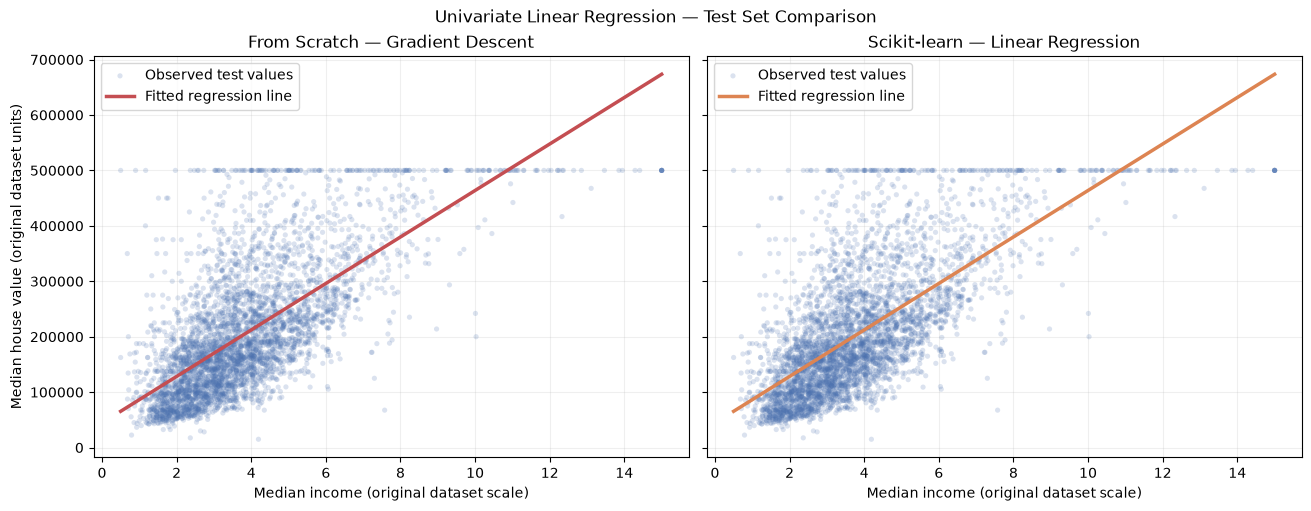

In [9]:
# Construct an ordered plotting grid on the original predictor scale.
# Ordering avoids connecting predictions in random observation order.
income_grid = pd.DataFrame({
    FEATURE: np.linspace(
        X_test[FEATURE].min(),
        X_test[FEATURE].max(),
        300,
    )
})

# Apply the training scaler without learning any new parameters.
income_grid_scaled = scaler.transform(income_grid)

# Use the already-fitted models to calculate points along each line.
scratch_line = predict_linear(
    income_grid_scaled,
    theta_0,
    theta_1,
)
sklearn_line = sklearn_model.predict(income_grid_scaled)

# Shared axes make both panels directly comparable.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

plot_settings = [
    ("From Scratch — Gradient Descent", scratch_line, "#C44E52"),
    ("Scikit-learn — Linear Regression", sklearn_line, "#DD8452"),
]

for ax, (title, fitted_line, line_color) in zip(axes, plot_settings):
    # Show all test observations; transparency reduces overplotting.
    ax.scatter(
        X_test[FEATURE],
        y_test,
        s=14,
        alpha=0.20,
        color="#4C72B0",
        edgecolors="none",
        label="Observed test values",
    )

    ax.plot(
        income_grid[FEATURE],
        fitted_line,
        color=line_color,
        linewidth=2.5,
        label="Fitted regression line",
    )

    ax.set_title(title)
    ax.set_xlabel("Median income (original dataset scale)")
    ax.grid(alpha=0.20)
    ax.set_axisbelow(True)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.legend(loc="upper left")

axes[0].set_ylabel("Median house value (original dataset units)")
fig.suptitle("Univariate Linear Regression — Test Set Comparison")

plt.show()

## 8. Results, Conclusions, and Team Handoff

### Test Results

Both implementations produced the same metrics at the displayed
precision on the 4,128 test observations:

| Model | RMSE | MAE | R² |
|---|---:|---:|---:|
| From scratch | 84,209.01 | 62,990.87 | 0.4589 |
| Scikit-learn | 84,209.01 | 62,990.87 | 0.4589 |

### Interpretation

- **Implementation agreement:** The nearly identical fitted
  parameters, regression lines, and evaluation metrics indicate
  that gradient descent reached a solution close to scikit-learn's
  least-squares solution for this experiment.

- **MAE:** Predictions differ from observed median house values
  by approximately 62,990.87 target units on average in absolute
  terms. This is an average error, not a maximum error or a
  guaranteed prediction interval.

- **RMSE:** The value of 84,209.01 is higher than MAE, reflecting
  the greater influence of large prediction errors when errors
  are squared.

- **R²:** The model accounts for approximately 45.89% of the
  test-set variation around the test-target mean under the R²
  definition. This does not mean that 45.89% of predictions
  are correct.

### Visual Findings

Both fitted lines show a positive relationship between median
income and median house value.

The spread of observations around the lines shows that income
alone does not capture all variation in the target. Observations
with similar income can have substantially different house values.

A horizontal concentration of observations is visible near
500,000 target units. Its source should be verified against the
dataset documentation before treating these observations as errors.
They were retained in this experiment.

At high income values, the fitted lines extend above the observed
target maximum. Ordinary linear regression does not constrain
predictions to the range of observed target values.

### Conclusion and Scope

The notebook completes the required univariate comparison using
the predictor and target selected in Part 1.

Median income captures part of the observed relationship with
median house value, but substantial prediction error remains.
These results do not establish sufficient accuracy for a specific
operational decision because no acceptable error threshold was
defined in the assignment.

Evaluation applies to the selected California dataset and this
random train/test split. Performance on Ontario data, future data,
or other populations has not been assessed.

### Handoff for Modularization

The following functions are available for reuse:

- `predict_linear`: predictions from an intercept and one slope.
- `mse_cost`: mean squared error calculation.
- `fit_linear_regression_gd`: scratch model training.
- `evaluate_regression`: RMSE, MAE, and R² calculation.

Current experiment settings:

| Setting | Value |
|---|---|
| Predictor | `median_income` |
| Target | `median_house_value` |
| Test proportion | 0.20 |
| Random seed | 42 |
| Predictor scaling | StandardScaler fitted on training data only |
| Scratch learning rate | 0.01 |
| Scratch iterations | 1,000 |

The preprocessing, model fitting, evaluation, and plotting sections
are ready to be transferred into the corresponding project modules
by the teammate responsible for modularization.

The source CSV and SQLite database were not overwritten.
All preparation and predictions were performed in memory.